## Student Name: 

---

# Tutorial 2: linear regression

All the parts that require action (either in the code or equations) are flagged by `<your turn>` or $\color{red}{<your~turn>}$

In [1]:
import numpy as np
import scipy.stats as st
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pylab as plt

az.style.use("arviz-vibrant")


# Setting matplotlib fonts
from matplotlib import rc
font = {'family': 'serif',
        'size': '14'}
rc('font', **font)


# Below is a set of colors for matplotlib that is colorblind-friendly
# To use them in plotting commands, you can simply set "color=colorset[N]",
# where N is an integer in [0,16), reflecting the index of the colors below.
COLORSET = ['#000000','#00270C','#00443C','#005083',
            '#034BCA','#483CFC','#9C2BFF','#EB24F4',
            '#FF2DC2','#FF4986','#FF7356','#FFA443',
            '#EBD155','#D3F187','#D7FFC8','#FFFFFF']

### Data

Starting with the example in the lecture, we have made $N$ independent measurements of a quantity $Y$ (with each measurement containing normally-distributed uncertainties), at different values of quantity $X$. Assuming $Y$ as a function of $X$, we want to infer a model for the "model" $Y$ (which we label $Y_{\rm{Model}}$), given what we can *observe* as $Y$ ($Y_{\rm{obs}}$).


Our data consists of three numbers per measurement:

$$ x = [x_1,\cdots,x_N] $$
$$ \hat{y}_{\rm{obs}} = [\hat{y}_1,\cdots,\hat{y}_N] $$
$$ \hat{\sigma} = [\hat{\sigma}_1,\cdots,\hat{\sigma}_N] $$


In this unit we will use [Pandas](https://pandas.pydata.org/) for data operations. Here is [a quick cheat sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf) for using Pandas.

In [2]:
# reading locally:
DATA = pd.read_csv('T2_data.csv')
# reading directly from the repo:
#DATA = pd.read_csv('https://raw.githubusercontent.com/bersavosh/P4003/refs/heads/main/Tutorials/T2_data.csv')
DATA.head()

,x,y_obs,sigma_obs
0,5.045212,36.022898,4.217411
1,5.093404,34.720167,4.539599
2,5.270117,39.367401,4.115512
3,5.420254,42.097764,5.384739
4,5.456610,27.912342,4.451724


### EDA
#### Exercise: Make a scatter plot the measurements and uncertainties of $\hat{y}_{\rm{obs}}$ as a function of $x$. To do this, you can simply use `plt.errorbar()` in matplotlib.

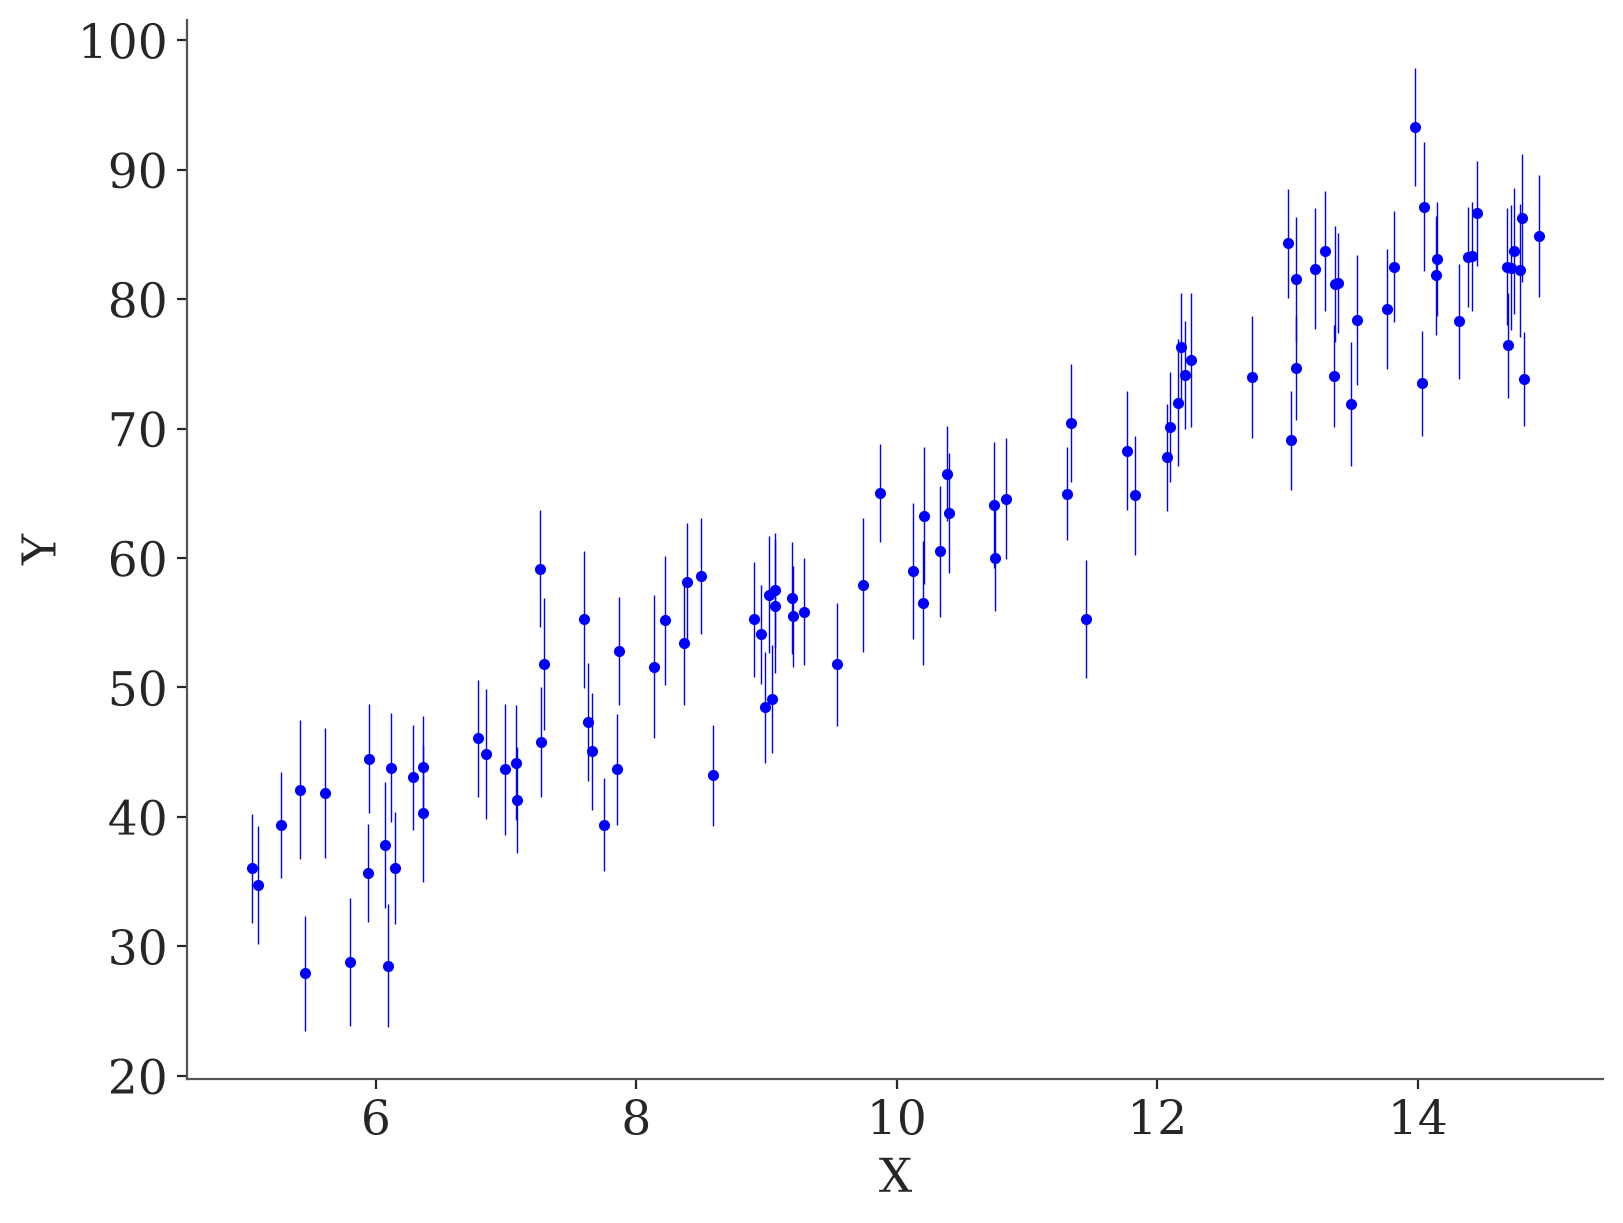

In [3]:
# <your turn>

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.errorbar(x=DATA['x'],
            yerr=DATA['sigma_obs'],
            y=DATA['y_obs'],
            fmt='.b', elinewidth=0.5)

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

### Our model

Similar to the lecture, we assume that our understanding of the physics, hypothetically, suggest that 
$$ Y_{\rm{Model}}(x; m, d) = m x + d $$

and similar to the lecture we assume the following priors on $m$ and $d$:

$$ m \sim \textrm{Uniform}(\min=0,\max=10) $$
$$ d \sim \textrm{Uniform}(\min=-20,\max=20) $$

and we define that

$$ \hat{Y}_{\rm{obs}} \sim \textrm{Normal}(Y_{\rm{Model}}(x),\sigma_Y) $$

and we remember that we consider $\hat{y}_{\rm{obs}} = [\hat{y}_1,\cdots,\hat{y}_N]$ as random draws of $\hat{Y}_{\rm{obs}}$.



#### Exercise - part a: Build a PyMC model with the variables above. With the following steps:
 - Start with the data. Data can be defined in a PyMC model using `pm.Data`.
 - Then add the model parameters and variables we have defined above.

In [4]:
# <your turn>
# just define the model and its components, no sampling or plotting needed here.

with pm.Model() as regression_model:
    ## First define your data here:
    x = pm.Data('x', DATA['x'])
    y_obs = pm.Data('y_obs', DATA['y_obs'])
    sigma_obs = pm.Data('sigma_obs', DATA['sigma_obs'])

    ## Now define your model variables
    m = pm.Uniform('m', 0, 10)
    d = pm.Uniform('d', -20, 20)
    Y_model = pm.Deterministic('Y_model', m*x+d)
    Y_obs = pm.Normal('Y_obs', mu=Y_model, sigma=sigma_obs)

# No plotting or sampling needed yet.

#### Exercise - part b: Explore the model structures by making a diagram of model's [plate notation](https://en.wikipedia.org/wiki/Plate_notation). For this purpose, you can use `pm.model_to_graphviz` (see documentation [here](https://www.pymc.io/projects/docs/en/v5.6.1/api/generated/pymc.model_to_graphviz.html)).

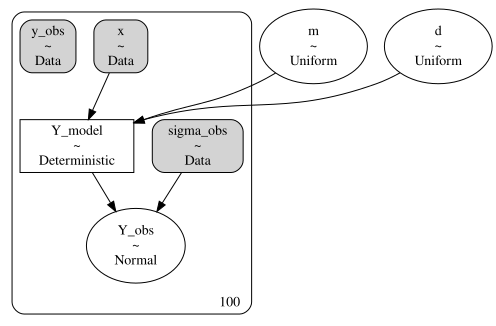

In [5]:
# <your turn>

pm.model_to_graphviz(regression_model)

#### Exercise - part c: Our model has a problem, can you spot it? fix the issue in the cell below and replot the plate notation. 
(*hint: where is the link between our data and $\hat{Y}_{\rm{obs}}$ variable?*)

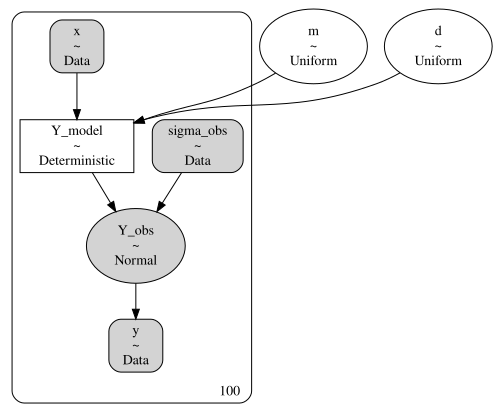

In [6]:
# <your turn>
# redefine the model and replot the model graph

with pm.Model() as regression_model:
    ## First define your data here:
    x = pm.Data('x', DATA['x'])
    y_obs = pm.Data('y', DATA['y_obs'])
    sigma_obs = pm.Data('sigma_obs', DATA['sigma_obs'])

    ## Now define your model variables
    m = pm.Uniform('m',0,10)
    d = pm.Uniform('d',-20,20)
    Y_model = pm.Deterministic('Y_model', m*x+d)
    Y_obs = pm.Normal('Y_obs', mu=Y_model, sigma=sigma_obs, observed=y_obs)


# graph visualization can be put under here
pm.model_to_graphviz(regression_model)

### MCMC sampling

Note that we are now actually performing MCMC (and not MC).

#### Exercise - part a: perform sampling with the model we defined above. Run your sampling with `discard_tuned_samples=False`.

In [7]:
# <your turn>

with regression_model:
    regression_mcmc_sample = pm.sample(discard_tuned_samples=False, draws=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m, d]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


#### Exercise - part b: Assess sampling performance. Think about what the sampling progress bar and table show. Print the resulting inference data `regression_mcmc_sample` to explore what is captured.

In [8]:
# <your turn>

regression_mcmc_sample

<xarray.DataTree>
Group: /
├── Group: /warmup_posterior
│       Dimensions:        (chain: 4, draw: 1000, Y_model_dim_0: 100)
│       Coordinates:
│         * chain          (chain) int64 32B 0 1 2 3
│         * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│         * Y_model_dim_0  (Y_model_dim_0) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
│       Data variables:
│           m              (chain, draw) float64 32kB 3.874 3.874 3.874 ... 5.207 5.203
│           d              (chain, draw) float64 32kB -8.421 -8.421 -8.421 ... 7.8 8.193
│           Y_model        (chain, draw, Y_model_dim_0) float64 3MB 11.12 ... 85.87
│       Attributes:
│           created_at:                 2026-08-07T00:06:42.727740+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              3.9092164039611816
│           tuning_steps:               1000
├── Group: /posterior
│       Dimensions:        (chain: 4, draw: 1000, Y_model_dim_0: 100)
│       Coordinates:
│         * chain          (chain) int64 32B 0 1 2 3
│         * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│         * Y_model_dim_0  (Y_model_dim_0) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
│       Data variables:
│           m              (chain, draw) float64 32kB 5.039 5.227 5.209 ... 5.07 5.096
│           d              (chain, draw) float64 32kB 9.928 8.03 7.891 ... 9.389 9.436
│           Y_model        (chain, draw, Y_model_dim_0) float64 3MB 35.35 ... 85.51
│       Attributes:
│           created_at:                 2026-08-07T00:06:42.732740+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              3.9092164039611816
│           tuning_steps:               1000
├── Group: /warmup_sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           step_size_bar          (chain, draw) float64 32kB 0.4909 0.1238 ... 0.2972
│           process_time_diff      (chain, draw) float64 32kB 0.1078 ... 0.0002654
│           reached_max_treedepth  (chain, draw) bool 4kB False False ... False False
│           perf_counter_diff      (chain, draw) float64 32kB 0.1078 ... 0.0002652
│           tree_depth             (chain, draw) int64 32kB 1 1 1 1 1 3 ... 2 3 5 4 4 2
│           diverging              (chain, draw) bool 4kB True True True ... False False
│           ...                     ...
│           smallest_eigval        (chain, draw) float64 32kB nan nan nan ... nan nan
│           step_size              (chain, draw) float64 32kB 0.4909 0.0484 ... 0.1909
│           max_energy_error       (chain, draw) float64 32kB 9.859e+04 ... 1.345
│           perf_counter_start     (chain, draw) float64 32kB 2.425e+05 ... 2.425e+05
│           largest_eigval         (chain, draw) float64 32kB nan nan nan ... nan nan
│           energy_error           (chain, draw) float64 32kB 0.0 0.0 ... -0.1521 0.193
│       Attributes:
│           created_at:                 2026-08-07T00:06:42.745003+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│    

#### Exercise - part c: Use `az.plot_trace` to look at how your chains have "walked" (use `var_names=['m','d']` to focus on just these parameters). First do this for `posterior` (the default), then do the same for `warmup_posterior`. Do you notice anything unusual?

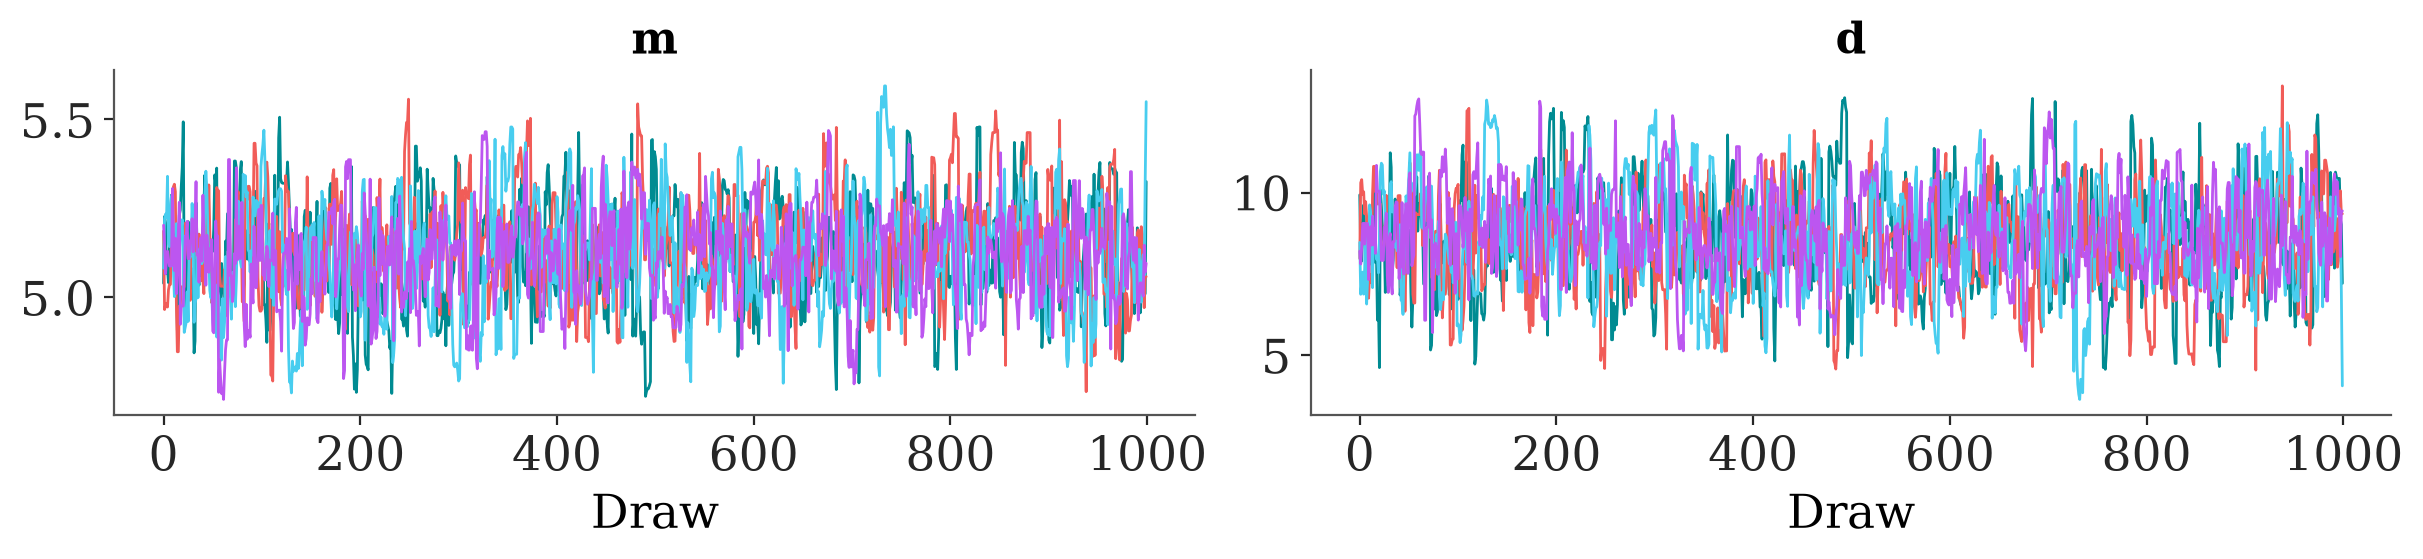

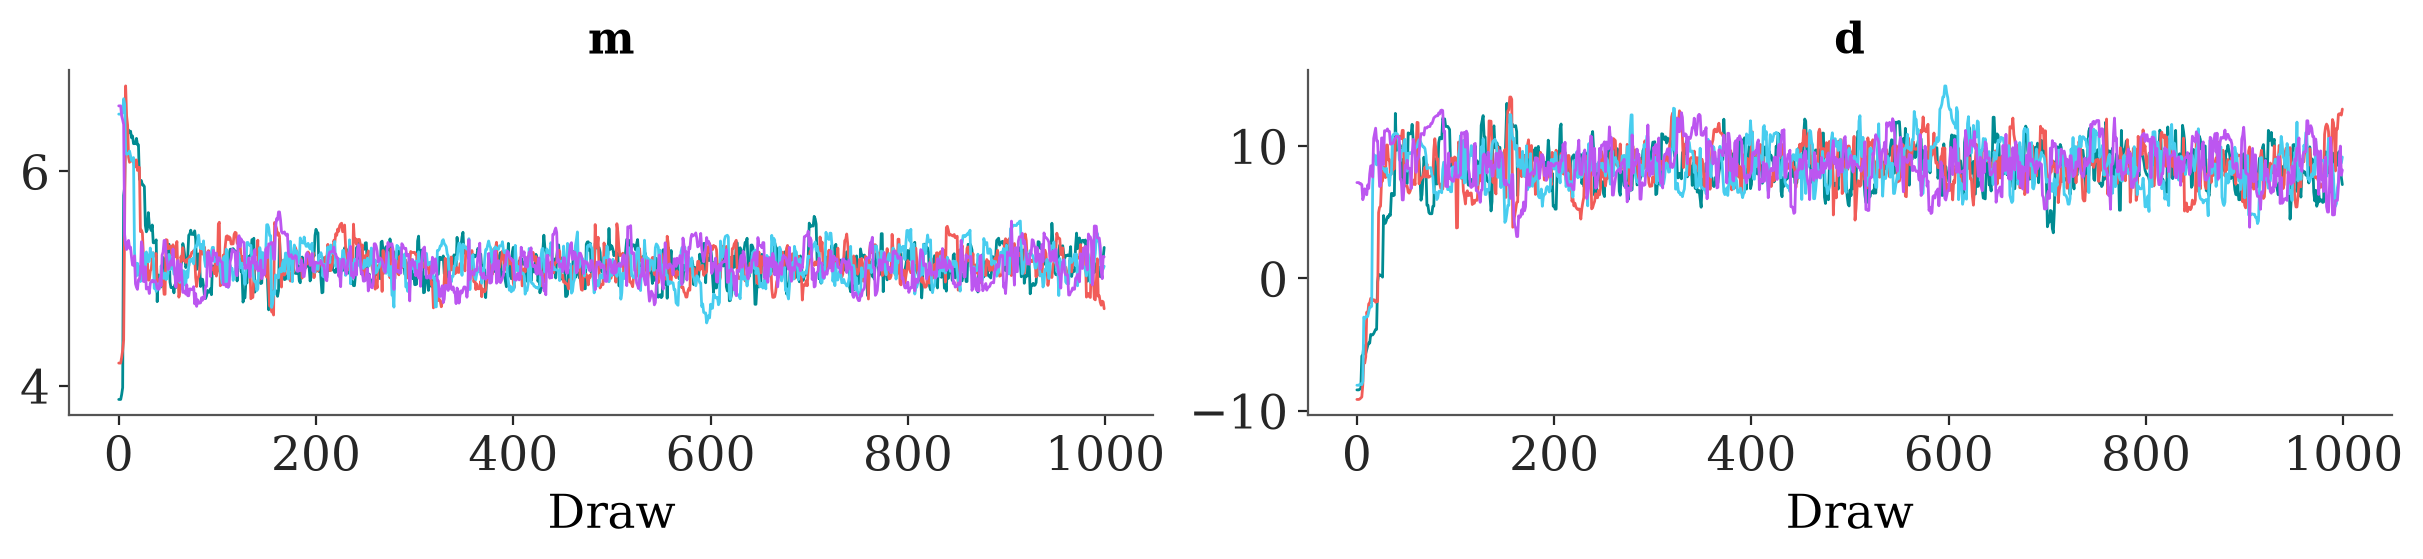

In [9]:
# <your turn>

# Posterior
az.plot_trace(regression_mcmc_sample, var_names=['m','d'], 
              visuals={'trace':{'width':1}}) # this defauls to "regression_mcmc_sample.posterior"

# Warmup
az.plot_trace(regression_mcmc_sample, group="warmup_posterior", var_names=['m','d'],
              visuals={'trace':{'width':1}})

### Model fitting results

#### Exercise - part a: Print summary of the posterior with `pm.summary`. Think about what the values in the summary table mean. Use 68% HDI probability for interval estimation.

In [10]:
# <your turn>

fit_summary = pm.stats.summary(regression_mcmc_sample, var_names=['m', 'd'], ci_prob=0.68, )
fit_summary

,mean,sd,eti68_lb,eti68_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
m,5.12,0.142,5,5.3,773,851,1.01,0.0051,0.0035
d,8.6,1.51,7.1,10,778,943,1.01,0.054,0.038


#### Exercise - part b: using plotting functions we have discussed in earlier exercises, plot the marginal posterior samples of $m$ and $d$.

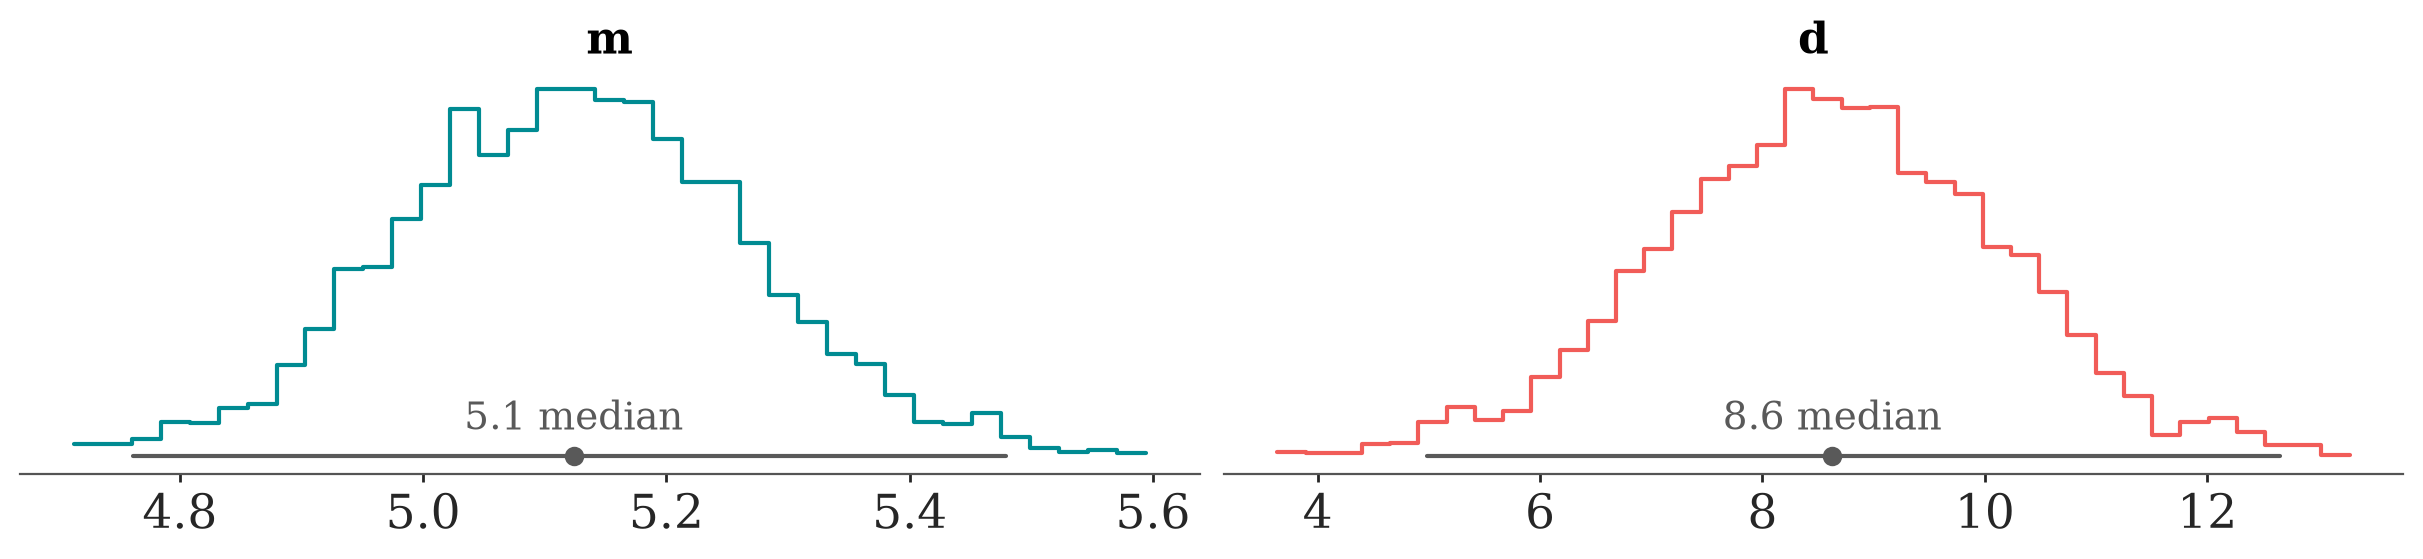

In [11]:
az.plot_dist(regression_mcmc_sample,
             var_names=['m','d'],
             point_estimate = 'median',
             ci_kind='hdi', ci_prob=0.99,
             kind="hist", 
             aes={"color": ["__variable__"]}
            );

#### Exercise - part c: using plotting functions we have discussed in earlier exercises, plot the joint and margian posterior samples of $m$ and $d$.

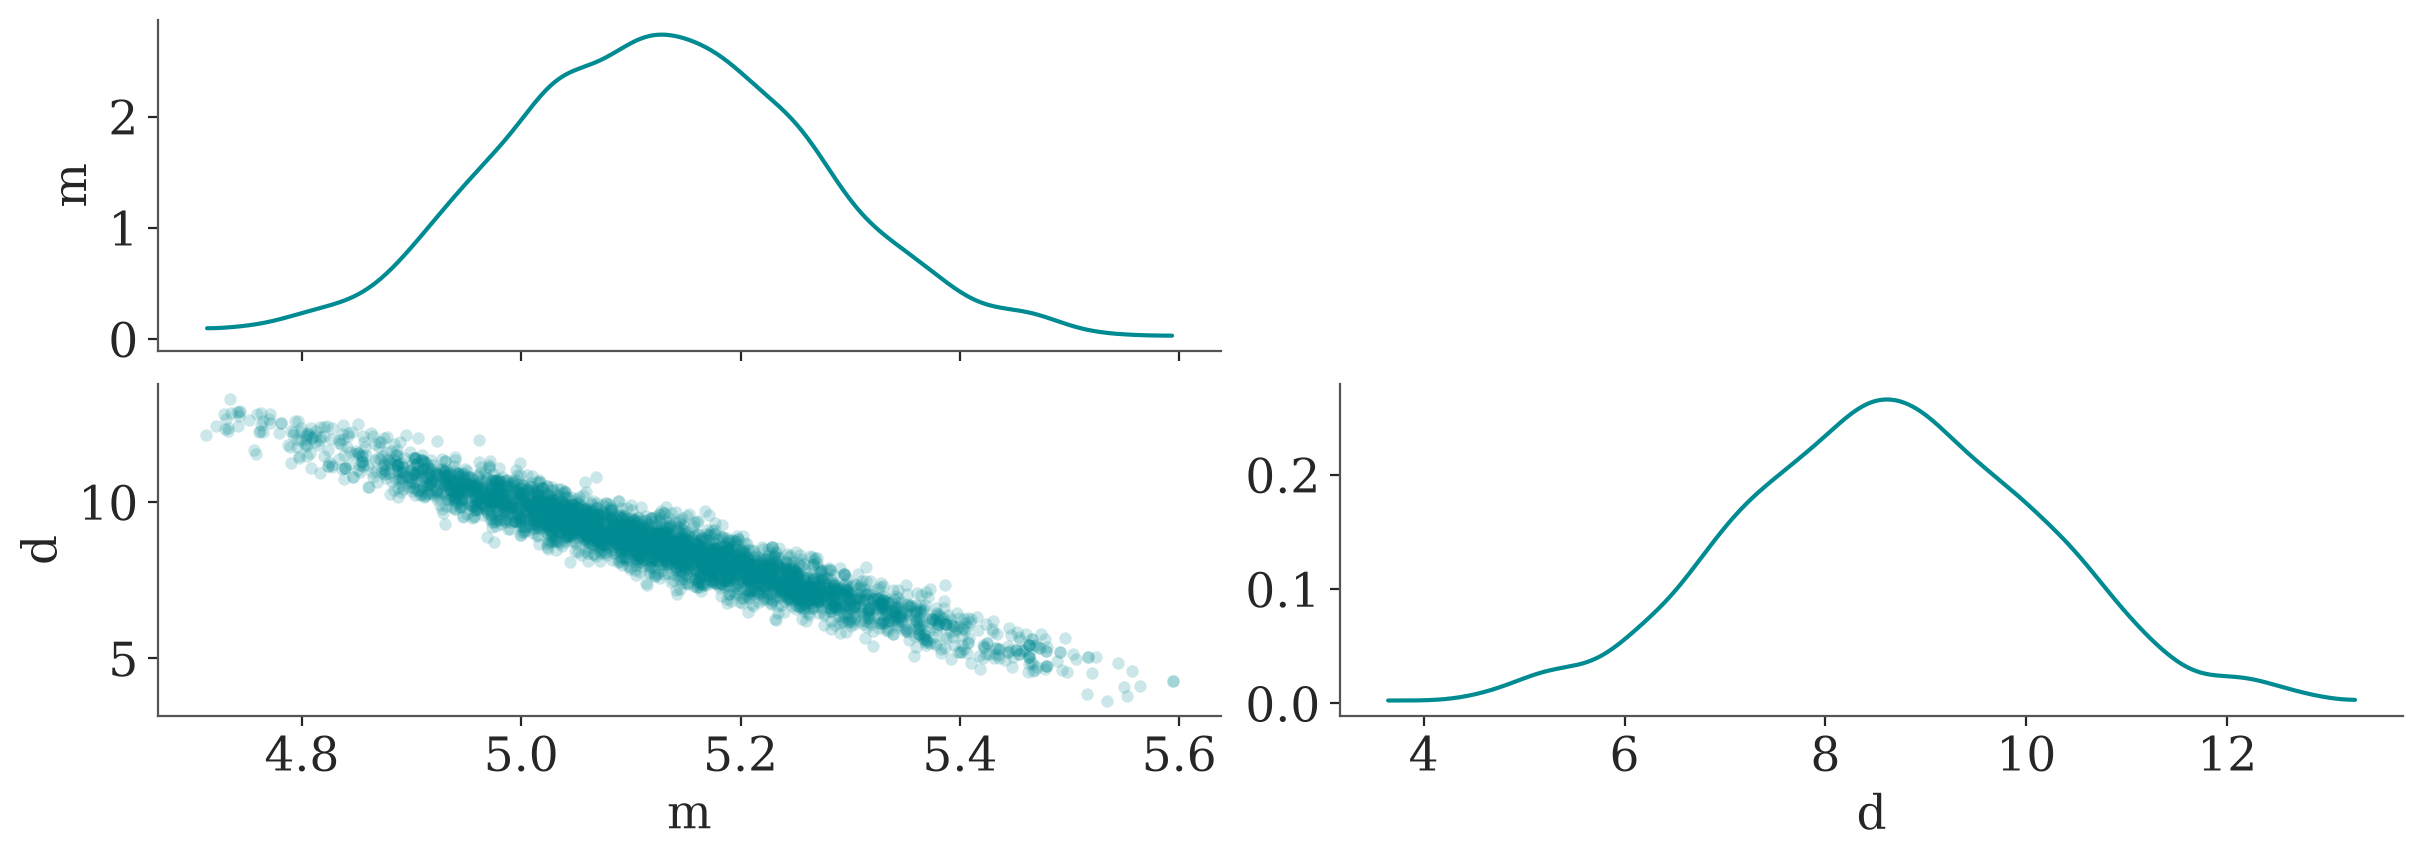

In [12]:
# <your turn>

az.plot_pair(regression_mcmc_sample, var_names=['m', 'd'], marginal=True,
             visuals={'scatter':{'alpha':0.2, 'size':20}})

#### Exercise - part d: Reuse your code from plotting the data, and add a line representing the model with posterior means.
*hint: you can extract the exact values from your inference data `regression_mcmc_sample.posterior['m'].mean().values`. You can also try using the XArray `data` group, instead of our initial Pandas data frame.

In [13]:
# You can find various ways to interact with XArrays, e.g.:
regression_mcmc_sample.posterior.median()

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:  ()
    Data variables:
        m        float64 8B 5.124
        d        float64 8B 8.627
        Y_model  float64 8B 60.56
    Attributes:
        created_at:                 2026-08-07T00:06:42.732740+00:00
        creation_library:           ArviZ
        creation_library_version:   1.2.0
        creation_library_language:  Python
        inference_library:          pymc
        inference_library_version:  6.2.0
        sample_dims:                ['chain', 'draw']
        sampling_time:              3.9092164039611816
        tuning_steps:               1000

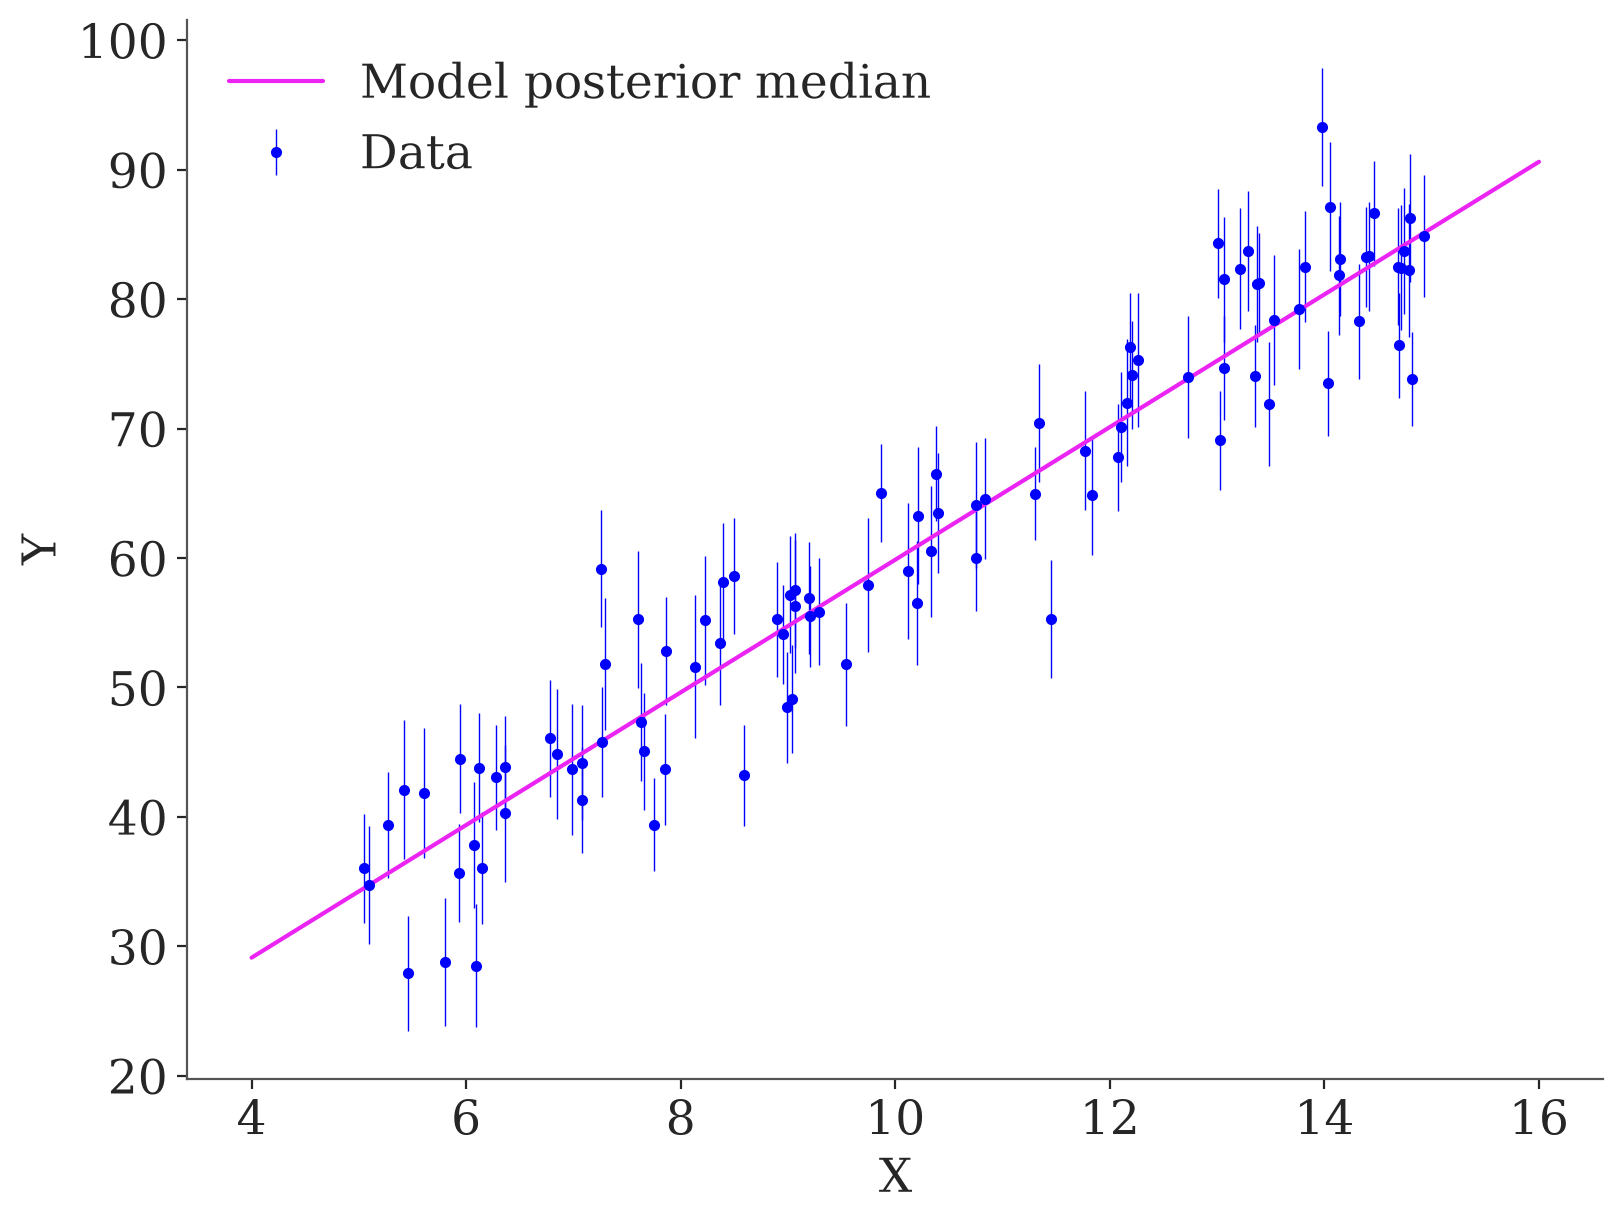

In [14]:
# <your turn>
mean_m = regression_mcmc_sample.posterior['m'].median().values
mean_d = regression_mcmc_sample.posterior['d'].median().values
test_x = np.linspace(4,16)
test_y = mean_m* test_x + mean_d

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)

# <your turn>

ax.errorbar(x=regression_mcmc_sample.constant_data['x'],
            yerr=regression_mcmc_sample.constant_data['sigma_obs'],
            y=regression_mcmc_sample.constant_data['y'],
            fmt='.b', elinewidth=0.5,label='Data')

ax.plot(test_x, test_y, color=COLORSET[7],label='Model posterior median')

ax.legend()

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

#### Exercise - part e: Reuse your code from plotting above, and plot a sample of lines using posteriors of $m$ and $d$.

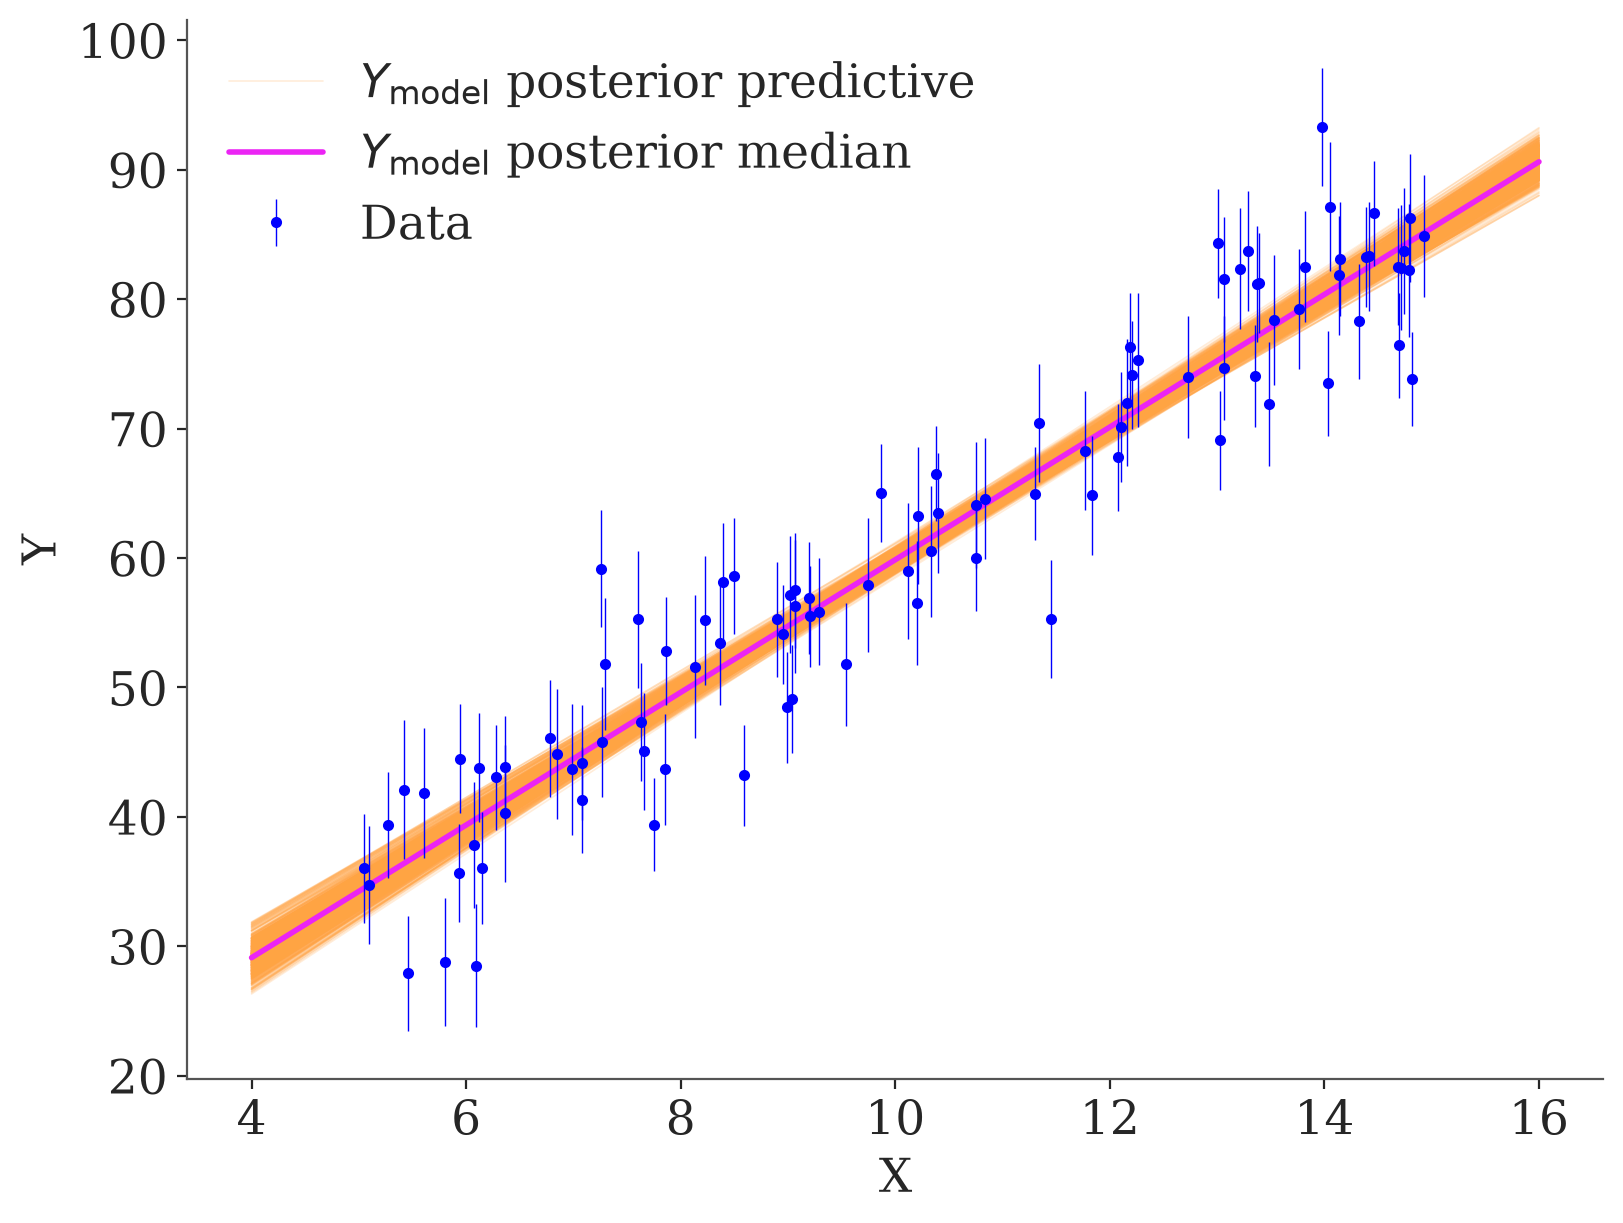

In [15]:
# <your turn>
mean_m = regression_mcmc_sample.posterior['m'].median().values
mean_d = regression_mcmc_sample.posterior['d'].median().values
test_x = np.linspace(4,16)
test_y = mean_m* test_x + mean_d

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

for i in range(1000):
    m = regression_mcmc_sample.posterior['m'][0,i].values
    d = regression_mcmc_sample.posterior['d'][0,i].values
    if i==0:
        ax.plot(test_x, test_x*m+d,lw=0.6,color=COLORSET[11],alpha=0.2, label=r'$Y_{\rm{model}}$ posterior predictive')
    else:
        ax.plot(test_x, test_x*m+d,lw=0.6,color=COLORSET[11],alpha=0.2)

ax.plot(test_x, test_y, color=COLORSET[7],label=r'$Y_{\rm{model}}$ posterior median',lw=2)


ax.errorbar(x=regression_mcmc_sample.constant_data['x'],
            yerr=regression_mcmc_sample.constant_data['sigma_obs'],
            y=regression_mcmc_sample.constant_data['y'],
            fmt='.b', elinewidth=0.5,label='Data')

ax.legend()

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

## Same plot with a shaded area using credible intervals

First we estimate the boundaries of the credible interval of interest (in this case, 95% HDI):

In [16]:
Y_model_ppc_hdi95 = az.hdi(regression_mcmc_sample,group='posterior',prob=0.95, var_names='Y_model')
Y_model_ppc_hdi95

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:        (Y_model_dim_0: 100, ci_bound: 2)
    Coordinates:
      * Y_model_dim_0  (Y_model_dim_0) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
      * ci_bound       (ci_bound) <U5 40B 'lower' 'upper'
    Data variables:
        Y_model        (Y_model_dim_0, ci_bound) float64 2kB 32.68 36.04 ... 86.64

One nice trick that Xarray data trees have is `sel` which allows us to *select* and slice our data tree:

In [17]:
## choosing all the lower bounds for 'Y_model'
Y_model_ppc_hdi95['Y_model'].sel({'ci_bound':'lower'})

<xarray.DataArray 'Y_model' (Y_model_dim_0: 100)> Size: 800B
array([32.68015718, 32.93813568, 33.89138915, 34.6972944 , 34.89245053,
       35.688685  , 36.73934089, 37.46404677, 37.51767467, 38.22334072,
       38.31888486, 38.47942484, 38.64059823, 39.38821509, 39.77763935,
       39.79006457, 42.13348333, 42.45506184, 43.21873787, 43.68845892,
       43.73301861, 44.68104856, 44.72852246, 44.86979694, 46.4653554 ,
       46.63863588, 46.76651258, 47.2521645 , 47.7655114 , 47.82825585,
       49.23793395, 49.70404163, 50.4835162 , 50.59743379, 51.12018217,
       51.61817531, 53.27763566, 53.59197767, 53.76732652, 53.930288  ,
       54.02534999, 54.14713406, 54.15617088, 54.84647752, 54.89280907,
       55.32318358, 56.62039962, 57.70155688, 58.34550642, 59.63124715,
       60.03166819, 60.07855135, 60.73303764, 60.99222906, 61.07406202,
       62.82366703, 62.8784476 , 63.31021269, 65.5518731 , 65.73128929,
       66.31077596, 67.90924219, 68.2121709 , 69.48296192, 69.5979136 ,
       69.87238394, 70.01426598, 70.12948001, 70.41430987, 72.73042379,
       74.13010794, 74.23985823, 74.42027979, 74.42638436, 75.08547685,
       75.45746689, 75.80113172, 75.87217378, 75.97049971, 76.4545587 ,
       76.7248681 , 77.85817768, 78.1521619 , 78.94577359, 79.23083029,
       79.29496745, 79.75005859, 79.78791996, 80.57675939, 80.92420945,
       81.07839417, 81.2799474 , 82.3944861 , 82.4073241 , 82.54509911,
       82.66618861, 82.85951191, 82.94002067, 83.00084208, 83.56424216])
Coordinates:
  * Y_model_dim_0  (Y_model_dim_0) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
    ci_bound       <U5 20B 'lower'

Now we will use `fill_between` from matplotlib:

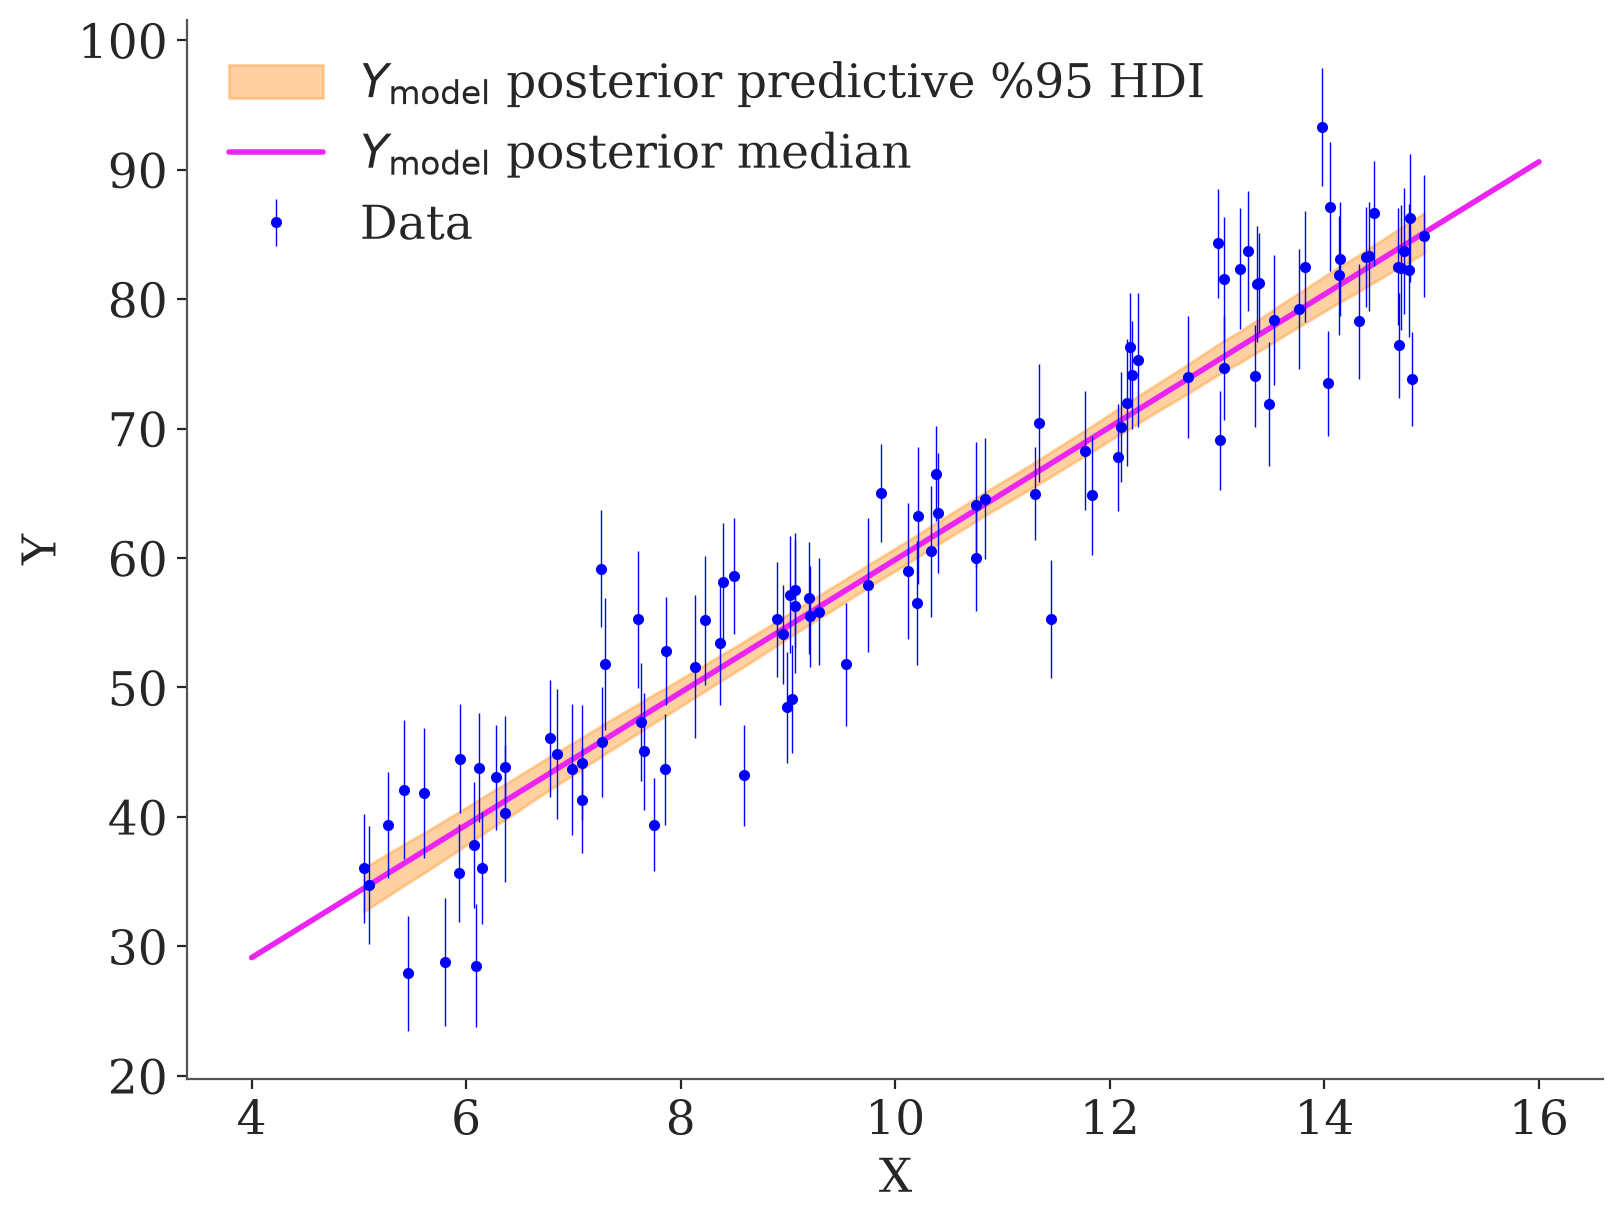

In [18]:
# <your turn>
mean_m = regression_mcmc_sample.posterior['m'].median().values
mean_d = regression_mcmc_sample.posterior['d'].median().values
test_x = np.linspace(4,16)
test_y = mean_m* test_x + mean_d

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.fill_between(regression_mcmc_sample.constant_data['x'],
                Y_model_ppc_hdi95['Y_model'].sel({'ci_bound':'lower'}),
                Y_model_ppc_hdi95['Y_model'].sel({'ci_bound':'upper'}),
                color=COLORSET[11], alpha=0.5,
                label=r'$Y_{\rm{model}}$ posterior predictive %95 HDI'
               )

ax.plot(test_x, test_y, color=COLORSET[7],label=r'$Y_{\rm{model}}$ posterior median',lw=2)


ax.errorbar(x=regression_mcmc_sample.constant_data['x'],
            yerr=regression_mcmc_sample.constant_data['sigma_obs'],
            y=regression_mcmc_sample.constant_data['y'],
            fmt='.b', elinewidth=0.5,label='Data')

ax.legend(loc=2)

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

Does the plot above look right? Does our approach make sense? Anything suspicious?

In [19]:
with regression_model:
    pm.sample_posterior_predictive(regression_mcmc_sample, extend_inferencedata=True)

Sampling: [Y_obs]


Output()

In [20]:
regression_mcmc_sample

<xarray.DataTree>
Group: /
├── Group: /warmup_posterior
│       Dimensions:        (chain: 4, draw: 1000, Y_model_dim_0: 100)
│       Coordinates:
│         * chain          (chain) int64 32B 0 1 2 3
│         * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│         * Y_model_dim_0  (Y_model_dim_0) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
│       Data variables:
│           m              (chain, draw) float64 32kB 3.874 3.874 3.874 ... 5.207 5.203
│           d              (chain, draw) float64 32kB -8.421 -8.421 -8.421 ... 7.8 8.193
│           Y_model        (chain, draw, Y_model_dim_0) float64 3MB 11.12 ... 85.87
│       Attributes:
│           created_at:                 2026-08-07T00:06:42.727740+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              3.9092164039611816
│           tuning_steps:               1000
├── Group: /posterior
│       Dimensions:        (chain: 4, draw: 1000, Y_model_dim_0: 100)
│       Coordinates:
│         * chain          (chain) int64 32B 0 1 2 3
│         * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│         * Y_model_dim_0  (Y_model_dim_0) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
│       Data variables:
│           m              (chain, draw) float64 32kB 5.039 5.227 5.209 ... 5.07 5.096
│           d              (chain, draw) float64 32kB 9.928 8.03 7.891 ... 9.389 9.436
│           Y_model        (chain, draw, Y_model_dim_0) float64 3MB 35.35 ... 85.51
│       Attributes:
│           created_at:                 2026-08-07T00:06:42.732740+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              3.9092164039611816
│           tuning_steps:               1000
├── Group: /warmup_sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           step_size_bar          (chain, draw) float64 32kB 0.4909 0.1238 ... 0.2972
│           process_time_diff      (chain, draw) float64 32kB 0.1078 ... 0.0002654
│           reached_max_treedepth  (chain, draw) bool 4kB False False ... False False
│           perf_counter_diff      (chain, draw) float64 32kB 0.1078 ... 0.0002652
│           tree_depth             (chain, draw) int64 32kB 1 1 1 1 1 3 ... 2 3 5 4 4 2
│           diverging              (chain, draw) bool 4kB True True True ... False False
│           ...                     ...
│           smallest_eigval        (chain, draw) float64 32kB nan nan nan ... nan nan
│           step_size              (chain, draw) float64 32kB 0.4909 0.0484 ... 0.1909
│           max_energy_error       (chain, draw) float64 32kB 9.859e+04 ... 1.345
│           perf_counter_start     (chain, draw) float64 32kB 2.425e+05 ... 2.425e+05
│           largest_eigval         (chain, draw) float64 32kB nan nan nan ... nan nan
│           energy_error           (chain, draw) float64 32kB 0.0 0.0 ... -0.1521 0.193
│       Attributes:
│           created_at:                 2026-08-07T00:06:42.745003+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│    

In [21]:
Y_obs_ppc_hdi95 = az.hdi(regression_mcmc_sample, group='posterior_predictive',prob=0.95, var_names='Y_obs')
Y_obs_ppc_hdi95

<xarray.DataTree 'posterior_predictive'>
Group: /posterior_predictive
    Dimensions:      (Y_obs_dim_0: 100, ci_bound: 2)
    Coordinates:
      * Y_obs_dim_0  (Y_obs_dim_0) int64 800B 0 1 2 3 4 5 6 ... 93 94 95 96 97 98 99
      * ci_bound     (ci_bound) <U5 40B 'lower' 'upper'
    Data variables:
        Y_obs        (Y_obs_dim_0, ci_bound) float64 2kB 25.81 42.53 ... 74.8 94.05

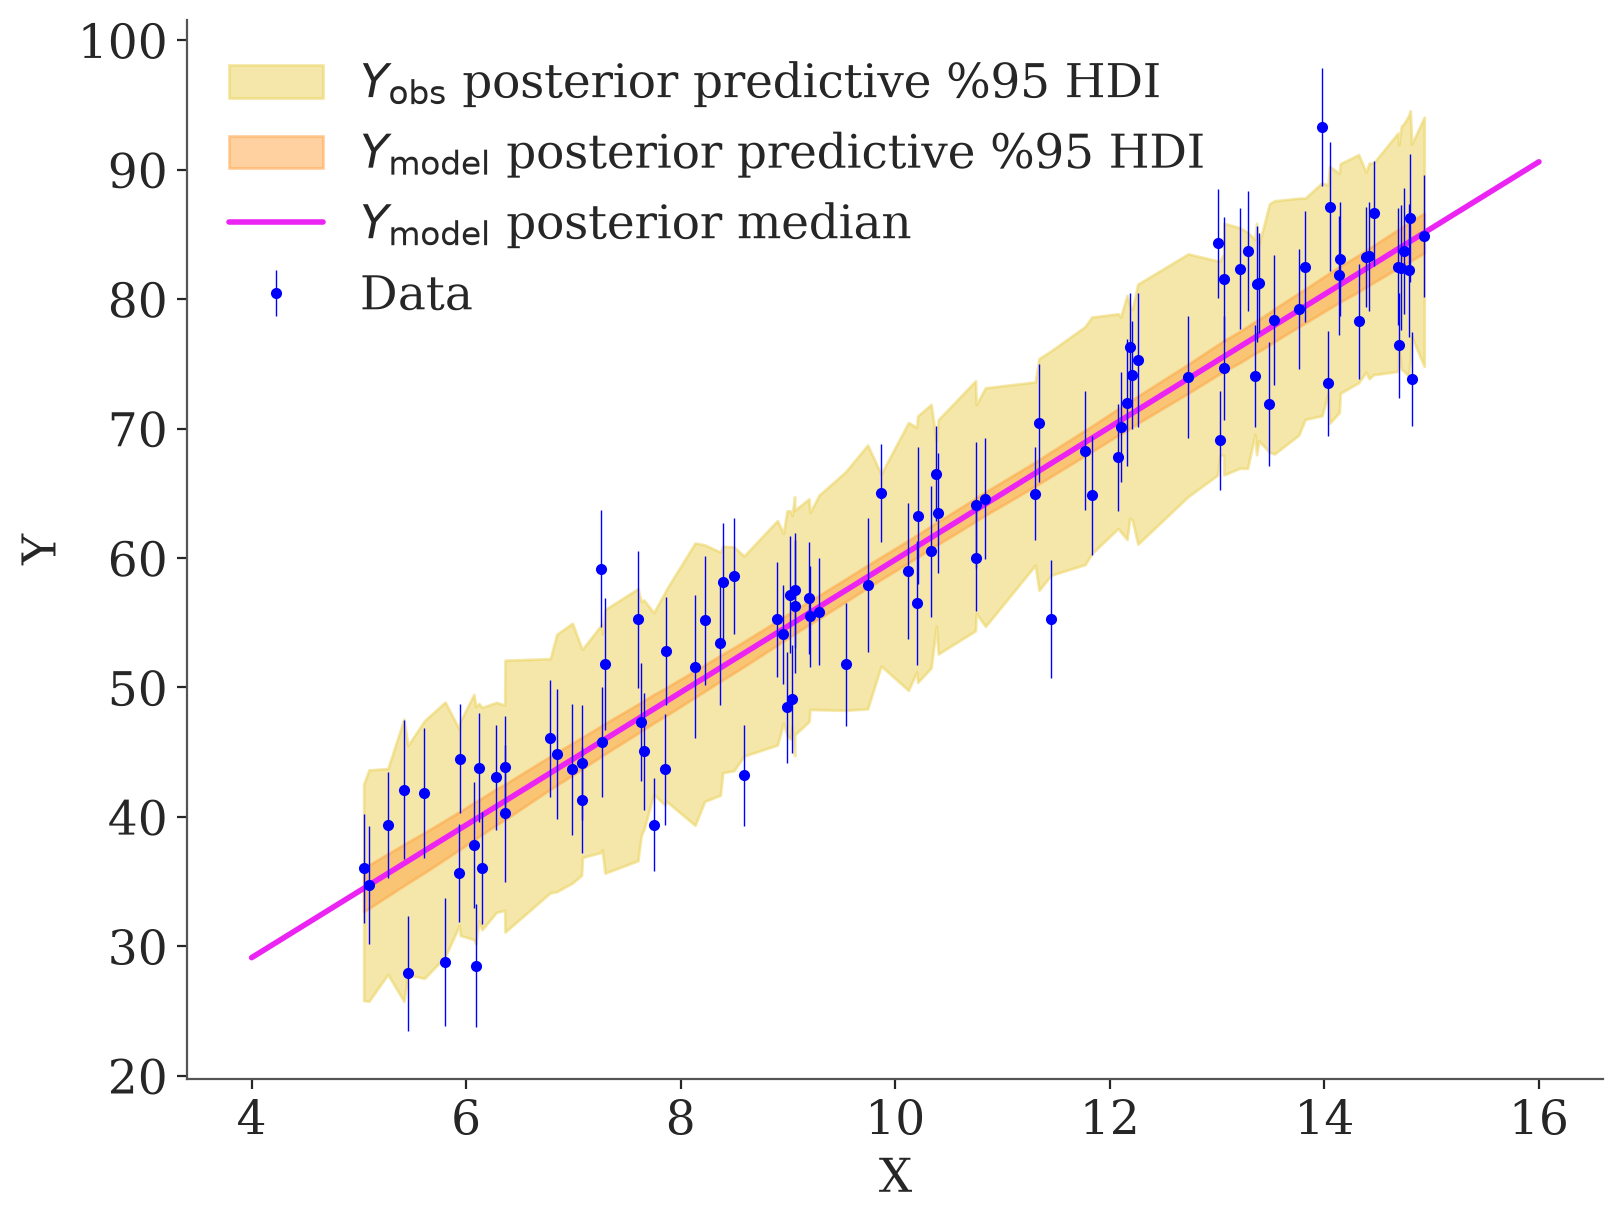

In [22]:
# <your turn>
mean_m = regression_mcmc_sample.posterior['m'].median().values
mean_d = regression_mcmc_sample.posterior['d'].median().values
test_x = np.linspace(4,16)
test_y = mean_m* test_x + mean_d

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.fill_between(regression_mcmc_sample.constant_data['x'],
                Y_obs_ppc_hdi95['Y_obs'].sel({'ci_bound':'lower'}),
                Y_obs_ppc_hdi95['Y_obs'].sel({'ci_bound':'upper'}),
                color=COLORSET[12], alpha=0.5,
                label=r'$Y_{\rm{obs}}$ posterior predictive %95 HDI'
               )


ax.fill_between(regression_mcmc_sample.constant_data['x'],
                Y_model_ppc_hdi95['Y_model'].sel({'ci_bound':'lower'}),
                Y_model_ppc_hdi95['Y_model'].sel({'ci_bound':'upper'}),
                color=COLORSET[11], alpha=0.5,
                label=r'$Y_{\rm{model}}$ posterior predictive %95 HDI'
               )

ax.plot(test_x, test_y, color=COLORSET[7],label=r'$Y_{\rm{model}}$ posterior median',lw=2)


ax.errorbar(x=regression_mcmc_sample.constant_data['x'],
            yerr=regression_mcmc_sample.constant_data['sigma_obs'],
            y=regression_mcmc_sample.constant_data['y'],
            fmt='.b', elinewidth=0.5,label='Data')

ax.legend(loc=2)

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

## Bonus content: out-of-sample predictions

What if we want to see our model performance for values of $x$ outside the existing sample?

In [23]:
prediction_x = np.linspace(4,16,100)
prediction_sigma = DATA['sigma_obs'].mean() * np.ones_like(prediction_x)
dummy_yobs = np.zeros_like(prediction_x)

with regression_model:
    pm.set_data({'x':prediction_x,'sigma_obs':prediction_sigma,'y':dummy_yobs})
    pm.sample_posterior_predictive(regression_mcmc_sample, extend_inferencedata=True, predictions=True)

Sampling: [Y_obs]


Output()

In [24]:
Y_obs_prediction_hdi95 = az.hdi(regression_mcmc_sample, group='predictions',prob=0.95, var_names='Y_obs')
Y_obs_prediction_hdi95

<xarray.DataTree 'predictions'>
Group: /predictions
    Dimensions:      (Y_obs_dim_0: 100, ci_bound: 2)
    Coordinates:
      * Y_obs_dim_0  (Y_obs_dim_0) int64 800B 0 1 2 3 4 5 6 ... 93 94 95 96 97 98 99
      * ci_bound     (ci_bound) <U5 40B 'lower' 'upper'
    Data variables:
        Y_obs        (Y_obs_dim_0, ci_bound) float64 2kB 19.95 37.8 ... 81.68 99.79

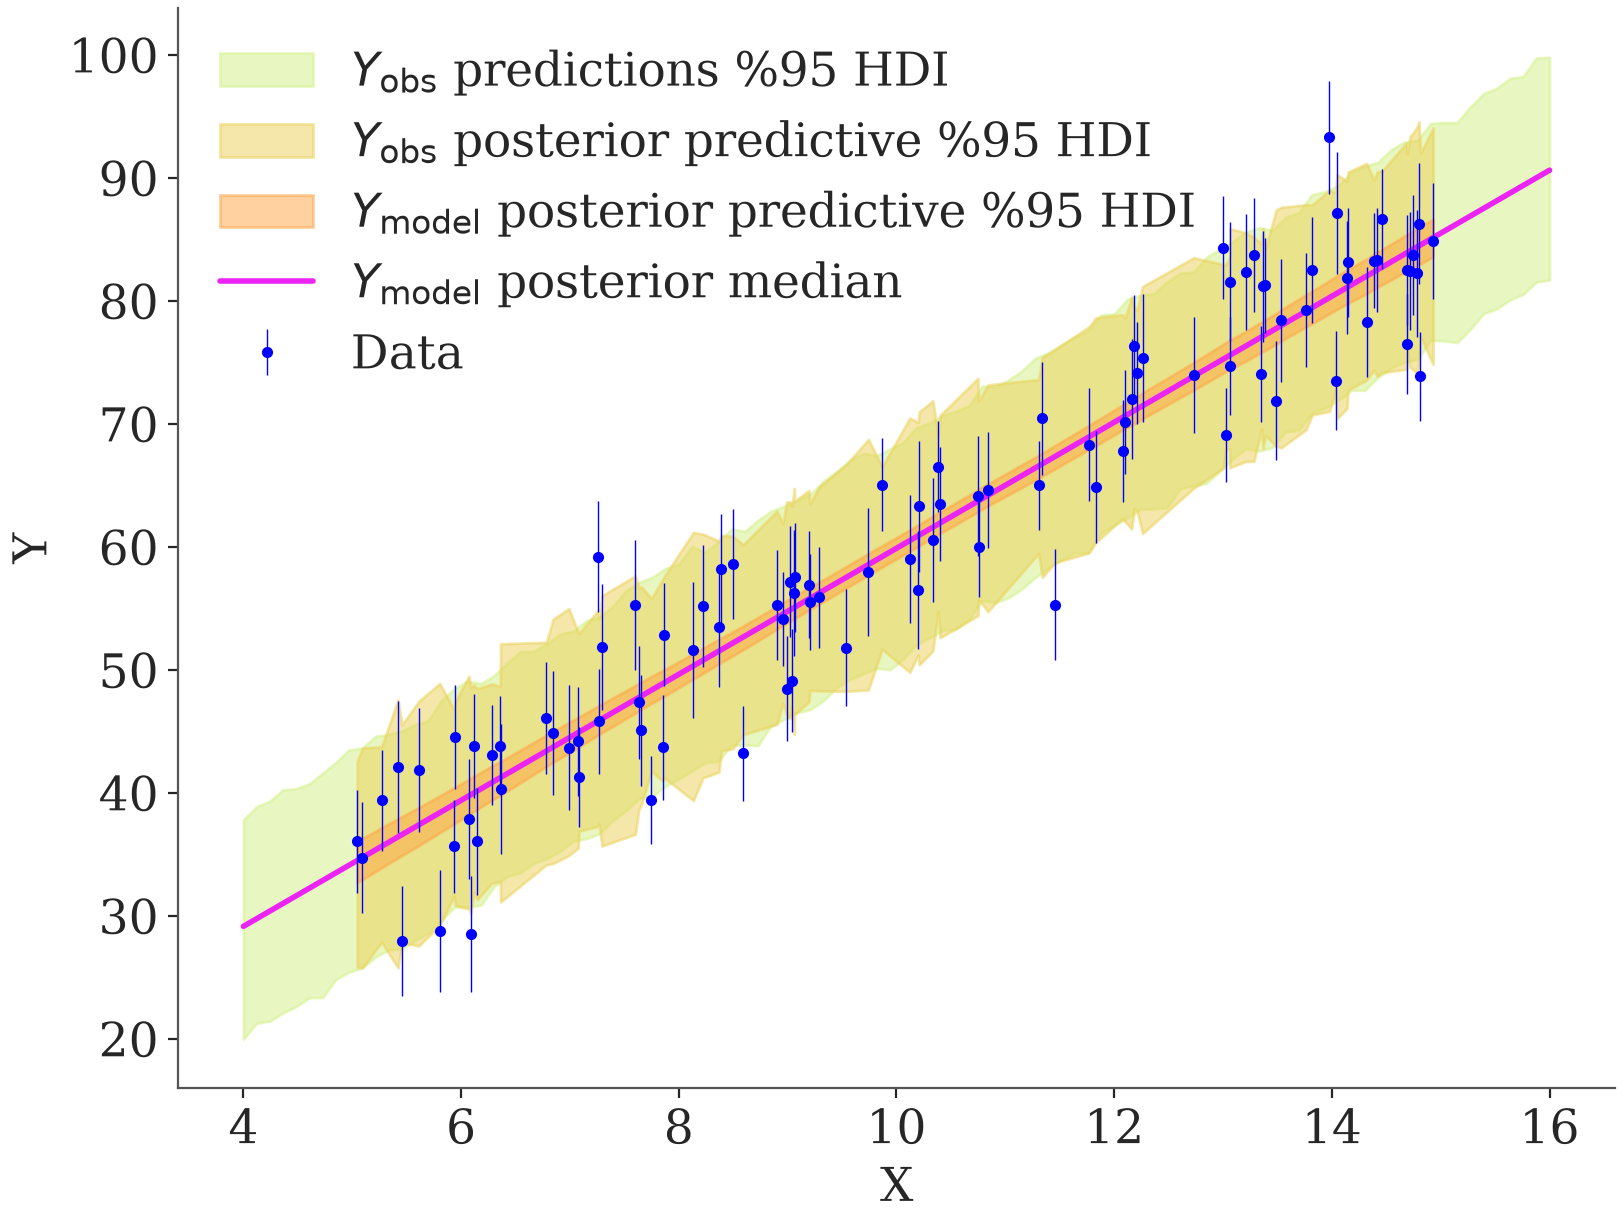

In [25]:
# <your turn>
mean_m = regression_mcmc_sample.posterior['m'].median().values
mean_d = regression_mcmc_sample.posterior['d'].median().values
test_x = np.linspace(4,16)
test_y = mean_m* test_x + mean_d

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.fill_between(regression_mcmc_sample.predictions_constant_data['x'],
                Y_obs_prediction_hdi95['Y_obs'].sel({'ci_bound':'lower'}),
                Y_obs_prediction_hdi95['Y_obs'].sel({'ci_bound':'upper'}),
                color=COLORSET[13], alpha=0.5,
                label=r'$Y_{\rm{obs}}$ predictions %95 HDI'
               )


ax.fill_between(regression_mcmc_sample.constant_data['x'],
                Y_obs_ppc_hdi95['Y_obs'].sel({'ci_bound':'lower'}),
                Y_obs_ppc_hdi95['Y_obs'].sel({'ci_bound':'upper'}),
                color=COLORSET[12], alpha=0.5,
                label=r'$Y_{\rm{obs}}$ posterior predictive %95 HDI'
               )


ax.fill_between(regression_mcmc_sample.constant_data['x'],
                Y_model_ppc_hdi95['Y_model'].sel({'ci_bound':'lower'}),
                Y_model_ppc_hdi95['Y_model'].sel({'ci_bound':'upper'}),
                color=COLORSET[11], alpha=0.5,
                label=r'$Y_{\rm{model}}$ posterior predictive %95 HDI'
               )

ax.plot(test_x, test_y, color=COLORSET[7],label=r'$Y_{\rm{model}}$ posterior median',lw=2)


ax.errorbar(x=regression_mcmc_sample.constant_data['x'],
            yerr=regression_mcmc_sample.constant_data['sigma_obs'],
            y=regression_mcmc_sample.constant_data['y'],
            fmt='.b', elinewidth=0.5,label='Data')

ax.legend(loc=2)

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

## You can now save the notebook and download it.